### Creating figure 1: Phase diagram for different hypergraphs

This notebook was used to create figure 2 of the paper 'Unveiling the impact of cross-order hyperdegree correlations in contagion processes on hypergraphs'. This figure was used to prove the accuarcy of our effective hyperdegree model and shows the phase diagram of an SIS process in three hypergraphs: a regular hypergraph where all nodes have $k_1=5$ and $k_2=3$; a hypergraph with Poisson-distributed hyperdegrees with means $\langle k_1 \rangle=5$ and $\langle k_2 \rangle=3$; and a hypergraph exhibiting truncated power-law hyperdegree distributions with characteristic exponents $\nu_1=2.5$ for pairwise interactions and $\nu_2=2.25$ for three-body interactions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import xgi as xgi
import random as random
import time

In [89]:
sim_reg_1 = np.loadtxt('../data/Phase_diagram/reg_I_steady_state1.txt')
sim_reg_2 = np.loadtxt('../data/Phase_diagram/reg_I_steady_state2.txt')

sim_pow_1 = np.loadtxt('../data/Phase_diagram/pow_I_steady_state1.txt')
sim_pow_2 = np.loadtxt('../data/Phase_diagram/pow_I_steady_state2.txt')

sim_poi_1 = np.loadtxt('../data/Phase_diagram/poi_I_steady_state1.txt')
sim_poi_2 = np.loadtxt('../data/Phase_diagram/poi_I_steady_state2.txt')


HOc_Poi_1 = np.loadtxt('../data/Phase_diagram/poi_prev1.txt')
HOc_Poi_2 = np.loadtxt('../data/Phase_diagram/poi_prev2.txt')

HOc_Reg_1 = np.loadtxt('../data/Phase_diagram/reg_prev1.txt')
HOc_Reg_2 = np.loadtxt('../data/Phase_diagram/reg_prev2.txt')

HOc_Pow_1 = np.loadtxt('../data/Phase_diagram/pow_prev1.txt')
HOc_Pow_2 = np.loadtxt('../data/Phase_diagram/pow_prev2.txt')


In [86]:
HOc_Reg_1=np.array(HOc_Reg_1)
HOc_Reg_1=HOc_Reg_1[::2]
HOc_Reg_2=np.array(HOc_Reg_2)
HOc_Reg_2=HOc_Reg_2[::2]

HOc_Pow_1=np.array(HOc_Pow_1)
HOc_Pow_2=np.array(HOc_Pow_2)

HOc_Poi_1=np.array(HOc_Poi_1)
HOc_Poi_1=HOc_Poi_1[::2]
HOc_Poi_2=np.array(HOc_Poi_2)
HOc_Poi_2=HOc_Poi_2[::2]

In [77]:
lambdas=np.linspace(0,2,int(len(HOc_Poi_1)))

sim_poi_1 = np.array(pd.read_csv('Files_minio/Poisson/sim_N1000_k15_k23_I_ss1.txt'))
sim_poi_2 = np.array(pd.read_csv('Files_minio/Poisson/sim_N1000_k15_k23_I_ss2.txt'))

sim_reg_1 = np.array(pd.read_csv('Files_minio/Regular/sim_N1000_k15_k23_I_ss1.txt'))
sim_reg_2 = np.array(pd.read_csv('Files_minio/Regular/sim_N1000_k15_k23_I_ss2.txt'))

#sim_pow_1 = np.array(pd.read_csv('Files_minio/Power_law/sim_N1000_gam125_gam2225_I_ss1.txt'))
#sim_pow_2 = np.array(pd.read_csv('Files_minio/Power_law/sim_N1000_gam125_gam2225_I_ss2.txt'))

In [78]:
print(len(HOc_Reg_1))

50


In [79]:
#sim_pow_2=[[0, 0, 0, 0, 0, 0, 0, 0, 31.78, 0, 0, 0, 0, 0, 0, 0, 0, 0, 31.78, 0, 0, 0, 35.16, 0, 0, 34.34, 0, 0, 30.8, 0, 35.02, 0, 0, 0, 0, 0, 0, 0, 32.28, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.9, 0, 31.32, 0, 32.04, 0, 0, 30.1, 31.76, 0, 0, 0, 0, 32.08, 0, 30.42, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 31.02, 0, 0, 0, 0, 0, 0, 32.42, 0, 34.82, 30.26, 0, 30.5, 0, 0, 0, 32.52, 33.88, 0, 0, 0, 0, 0], [0, 31.78, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.08, 0, 0, 0, 35.94, 31.36, 0, 0, 33.7, 0, 33.18, 0, 0, 0, 0, 0, 0, 30.46, 0, 0, 0, 0, 0, 0, 0, 0, 0, 34.58, 0, 0, 0, 0, 0, 32.88, 0, 0, 30.84, 32.5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.04, 0, 0, 0, 0, 0, 32.48, 0], [0, 31.78, 0, 0, 0, 0, 0, 0, 0, 34.02, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.04, 0, 0, 0, 0, 0, 0, 0, 31.4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 36.92, 0, 31.68, 31.24, 0, 33.6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 31.06, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 32.4, 0, 32.32, 0, 0, 0, 0, 0, 0, 0, 0, 31.18, 0, 0, 0, 30.46, 0, 0, 0, 0, 0], [31.26, 0, 0, 0, 0, 0, 0, 0, 33.9, 0, 30.1, 0, 0, 0, 30.08, 0, 0, 0, 32.26, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 35.94, 0, 0, 0, 0, 34.52, 0, 0, 0, 0, 37.36, 0, 34.56, 0, 0, 0, 0, 31.54, 0, 0, 0, 0, 0, 0, 31.16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 32.84, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.08, 30.66, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 32.12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 33.26, 0, 0, 33.78, 0, 0, 0, 0, 0, 0, 0, 30.3, 0, 0, 0, 0, 0, 0, 30.52, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 31.74, 0, 0, 0, 0, 0, 0, 34.16, 0], [0, 0, 0, 0, 32.24, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 31.22, 0, 0, 30.36, 30.3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.42, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.36, 0, 0, 0, 0, 0, 0, 31.58, 0, 0, 0, 0, 0, 30.98, 0, 0, 0, 0, 0, 0, 0, 30.1, 0, 0, 0, 30.54, 0, 0, 0, 0, 0, 0, 0, 0, 30.36, 0, 0, 31.92, 0, 0, 33.12, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 31.94, 0, 0, 0, 0, 0, 0, 34.72, 0, 32.12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 31.94, 0, 0, 0, 30.48, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 32.62, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 32.92, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 31.96, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 32.26, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 33.12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 31.72, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.76, 0, 0, 0, 0, 0, 35.38, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.56, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 32.0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.54, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 32.16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 119.82, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 34.64, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 77.18, 0, 0, 0, 0, 0, 0, 0, 0, 240.32, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 43.66, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 174.7, 0, 190.08, 0, 0, 0, 0, 0, 0, 0, 0, 0, 157.86, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 118.2, 0, 0, 0, 200.04, 0, 0, 0, 0, 0, 0, 119.7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60.48, 0, 0, 0, 0, 0, 0, 133.96, 0, 222.46, 141.38, 0, 0, 0, 0, 0, 0, 0, 218.08, 0, 0, 0, 224.96, 0, 121.84, 0, 190.84, 0], [0, 169.24, 0, 0, 0, 0, 0, 0, 190.94, 0, 0, 206.24, 0, 172.52, 0, 0, 0, 0, 0, 157.42, 217.08, 0, 63.24, 229.22, 224.84, 253.96, 254.16, 0, 0, 175.42, 0, 187.78, 0, 0, 0, 0, 0, 218.24, 181.32, 0, 0, 247.12, 0, 0, 0, 0, 0, 0, 182.94, 0, 0, 217.38, 0, 0, 0, 189.76, 191.28, 237.86, 0, 0, 0, 0, 0, 0, 189.26, 211.66, 0, 0, 0, 0, 146.98, 183.36, 111.92, 92.9, 139.08, 0, 227.9, 0, 0, 186.86, 203.96, 0, 0, 150.02, 0, 0, 243.76, 0, 171.22, 212.58, 0, 174.34, 134.42, 0, 0, 142.96, 0, 150.1, 37.26, 211.24], [279.64, 152.46, 0, 0, 212.58, 0, 137.28, 0, 220.4, 0, 86.38, 213.56, 0, 231.22, 250.3, 254.12, 0, 235.5, 177.78, 0, 0, 242.34, 225.12, 87.3, 241.54, 268.8, 143.84, 0, 259.74, 181.6, 0, 205.82, 159.08, 205.32, 0, 193.5, 150.7, 257.98, 242.52, 0, 128.78, 0, 220.74, 0, 232.36, 0, 0, 0, 239.36, 0, 198.0, 104.18, 0, 203.8, 0, 323.04, 0, 0, 76.2, 183.06, 0, 0, 234.08, 248.04, 183.28, 197.88, 0, 241.84, 0, 0, 275.74, 182.96, 251.62, 171.1, 0, 176.88, 226.28, 0, 0, 0, 0, 0, 213.22, 244.2, 0, 178.84, 0, 0, 207.12, 0, 0, 0, 220.54, 183.14, 273.36, 133.96, 0, 258.18, 215.18, 0], [127.54, 257.2, 238.9, 230.66, 252.68, 233.18, 0, 249.1, 232.98, 179.98, 158.3, 238.24, 284.34, 270.1, 241.76, 225.4, 256.1, 236.88, 184.54, 263.8, 213.12, 261.3, 207.28, 212.8, 0, 0, 188.92, 63.64, 301.62, 225.86, 200.7, 190.6, 168.3, 0, 254.66, 249.46, 256.48, 173.38, 223.66, 0, 252.08, 225.7, 201.6, 202.42, 219.72, 237.6, 135.56, 257.12, 213.12, 262.26, 236.98, 0, 240.9, 222.16, 235.34, 0, 254.36, 205.3, 138.42, 217.82, 0, 287.92, 0, 256.4, 0, 0, 222.42, 214.22, 206.7, 236.86, 236.88, 267.26, 164.38, 195.78, 237.52, 206.74, 0, 218.86, 0, 160.4, 257.5, 200.1, 50.86, 227.78, 239.62, 214.3, 31.1, 0, 187.7, 226.14, 269.36, 181.62, 158.6, 0, 248.52, 215.3, 212.98, 0, 270.82, 280.02], [208.68, 193.26, 230.18, 217.56, 254.14, 245.34, 276.0, 247.12, 302.16, 271.04, 343.36, 248.1, 262.24, 273.52, 297.44, 78.5, 242.4, 239.86, 221.8, 278.2, 223.02, 254.72, 254.98, 209.4, 225.72, 223.02, 251.2, 206.7, 232.82, 271.58, 287.14, 224.56, 292.02, 259.66, 250.6, 238.86, 236.94, 254.66, 280.18, 259.34, 295.64, 251.9, 223.18, 253.64, 270.24, 209.9, 240.4, 262.94, 204.12, 245.1, 0, 271.08, 0, 237.36, 218.1, 206.84, 242.68, 257.82, 262.98, 277.2, 255.74, 273.74, 241.16, 246.46, 168.28, 284.16, 189.64, 247.7, 281.4, 229.6, 294.48, 261.1, 244.3, 189.38, 250.6, 191.52, 280.2, 260.14, 243.12, 235.64, 206.6, 275.2, 188.4, 262.68, 227.46, 276.96, 0, 223.96, 236.02, 273.72, 258.34, 279.26, 253.86, 206.9, 238.92, 227.8, 205.28, 260.64, 276.2, 252.78], [311.92, 268.04, 269.3, 238.52, 238.2, 256.24, 250.02, 227.98, 313.44, 201.6, 255.76, 232.68, 230.14, 277.26, 194.46, 260.18, 302.68, 302.64, 248.28, 266.24, 245.06, 0, 275.98, 286.14, 262.5, 257.26, 279.26, 247.28, 252.76, 258.74, 284.2, 288.14, 220.96, 177.76, 250.12, 265.18, 259.54, 257.38, 290.68, 0, 265.64, 252.98, 273.52, 171.16, 235.44, 312.92, 307.84, 268.04, 257.18, 294.14, 202.08, 245.66, 219.26, 248.74, 238.36, 254.64, 230.94, 266.88, 283.3, 243.7, 283.7, 267.96, 283.3, 121.26, 248.18, 232.02, 269.28, 236.66, 258.26, 0, 257.62, 277.62, 255.2, 294.06, 224.34, 226.3, 272.68, 308.84, 261.88, 205.68, 315.64, 286.7, 232.3, 262.92, 283.42, 255.44, 327.8, 295.46, 248.88, 246.7, 235.52, 39.02, 242.46, 261.18, 262.46, 255.28, 253.82, 250.36, 310.6, 227.02], [284.42, 280.98, 255.92, 225.68, 300.18, 265.22, 278.24, 269.7, 289.34, 265.94, 320.54, 292.58, 236.88, 253.58, 287.06, 228.2, 258.98, 273.6, 259.18, 286.52, 286.68, 290.96, 297.92, 259.88, 286.82, 242.22, 257.3, 255.46, 231.62, 250.78, 277.26, 333.48, 335.18, 242.06, 300.18, 242.44, 259.22, 262.52, 299.26, 267.46, 254.46, 293.12, 327.52, 274.7, 220.5, 251.5, 303.18, 268.26, 272.86, 295.7, 278.84, 254.96, 234.5, 287.62, 260.32, 175.56, 270.06, 222.08, 294.76, 278.2, 275.46, 286.58, 256.34, 242.34, 253.44, 250.18, 288.84, 285.32, 278.76, 244.78, 210.62, 276.74, 308.2, 314.26, 205.78, 209.98, 253.9, 283.04, 252.68, 237.8, 0, 293.38, 277.72, 262.0, 277.22, 282.12, 243.74, 277.42, 314.94, 250.04, 239.74, 269.34, 277.38, 240.48, 258.54, 286.5, 287.0, 300.98, 277.76, 245.22], [306.26, 293.56, 286.86, 291.52, 252.46, 303.0, 307.18, 244.7, 281.12, 293.4, 251.54, 313.98, 260.5, 290.52, 237.58, 266.8, 270.3, 279.74, 307.02, 294.6, 267.48, 296.18, 237.0, 251.02, 206.34, 244.6, 256.72, 301.06, 283.02, 280.82, 320.3, 318.32, 208.38, 306.36, 271.42, 279.24, 275.54, 273.76, 252.34, 278.2, 241.2, 303.28, 264.46, 289.58, 256.62, 287.78, 312.48, 273.38, 303.58, 311.16, 325.42, 296.42, 258.58, 309.0, 232.92, 304.58, 270.16, 293.86, 236.52, 253.52, 259.24, 277.54, 267.12, 264.2, 267.52, 313.84, 319.0, 271.4, 245.94, 316.52, 255.02, 267.22, 274.98, 291.38, 299.5, 270.9, 218.5, 247.1, 245.14, 279.1, 305.72, 300.98, 287.18, 314.3, 286.68, 314.4, 276.72, 307.0, 264.72, 267.48, 280.16, 269.96, 266.22, 273.94, 261.96, 289.6, 247.34, 261.1, 265.46, 293.68], [303.44, 262.08, 313.6, 237.64, 256.6, 288.06, 274.34, 277.6, 335.44, 267.96, 290.94, 286.7, 270.92, 283.62, 252.24, 326.44, 293.98, 310.6, 286.2, 282.78, 282.44, 271.56, 315.1, 273.34, 277.78, 284.24, 237.42, 293.82, 241.0, 285.92, 285.24, 323.12, 287.92, 297.28, 343.42, 266.42, 252.48, 302.5, 286.5, 234.9, 239.62, 274.8, 323.58, 278.96, 313.7, 304.14, 262.56, 269.1, 309.78, 275.94, 275.54, 289.64, 273.8, 290.86, 309.14, 311.86, 289.98, 298.48, 303.78, 314.56, 260.24, 304.26, 287.26, 278.82, 278.02, 301.4, 263.0, 300.1, 314.38, 305.86, 283.66, 292.9, 351.84, 320.66, 223.5, 307.08, 236.68, 332.84, 309.58, 249.66, 301.84, 278.3, 317.64, 315.14, 274.0, 298.72, 323.9, 220.3, 294.42, 321.96, 315.74, 281.66, 293.08, 318.54, 293.28, 294.6, 243.32, 271.12, 263.14, 263.28], [279.62, 325.84, 296.66, 280.36, 307.86, 328.26, 244.26, 257.36, 344.6, 325.64, 256.42, 309.14, 282.6, 310.94, 336.68, 288.34, 345.8, 298.68, 262.02, 310.98, 356.12, 261.48, 304.34, 304.36, 299.34, 356.3, 271.1, 247.44, 268.68, 322.44, 275.86, 312.44, 314.7, 325.94, 296.3, 334.22, 296.72, 270.44, 305.72, 302.24, 334.58, 316.7, 239.22, 344.48, 316.72, 290.52, 290.88, 307.0, 305.06, 281.24, 304.34, 328.28, 287.54, 342.54, 308.34, 294.32, 290.22, 339.94, 264.0, 318.62, 297.28, 284.48, 301.94, 314.72, 296.68, 257.06, 289.9, 302.08, 279.44, 309.9, 307.02, 320.38, 299.5, 312.72, 295.4, 291.12, 294.34, 340.18, 339.0, 276.4, 299.78, 324.02, 349.38, 285.46, 290.76, 326.68, 285.22, 282.22, 309.38, 280.68, 274.18, 312.8, 281.08, 284.58, 303.02, 307.98, 322.2, 324.76, 249.48, 293.22], [338.4, 341.62, 346.16, 290.3, 314.68, 291.96, 310.24, 328.7, 329.74, 280.1, 343.5, 353.9, 283.94, 328.36, 283.72, 329.54, 256.34, 302.86, 272.48, 332.54, 295.8, 336.88, 327.5, 349.8, 282.82, 298.96, 313.38, 306.04, 337.6, 363.82, 319.98, 316.0, 328.92, 300.82, 334.68, 318.74, 309.1, 367.96, 342.38, 373.62, 314.1, 341.7, 315.18, 363.9, 329.56, 326.48, 330.04, 303.6, 357.42, 324.14, 285.62, 319.22, 276.34, 329.06, 300.82, 239.06, 326.32, 296.02, 300.66, 347.16, 326.44, 333.58, 310.66, 312.38, 301.92, 308.0, 257.1, 317.92, 336.06, 294.58, 341.74, 311.94, 370.86, 339.5, 306.86, 347.3, 294.2, 335.46, 346.98, 269.12, 378.82, 319.38, 342.66, 323.44, 337.46, 337.16, 366.08, 327.28, 285.32, 340.7, 258.46, 334.82, 318.24, 335.48, 296.92, 346.8, 285.94, 335.74, 309.78, 264.16], [338.28, 272.3, 342.3, 348.66, 315.72, 328.64, 358.96, 295.56, 297.72, 332.26, 306.96, 321.92, 345.22, 295.22, 344.32, 280.9, 319.28, 324.72, 349.92, 315.4, 326.26, 329.56, 328.64, 274.8, 352.02, 322.16, 321.68, 357.4, 286.76, 318.6, 329.46, 305.18, 331.04, 305.54, 280.54, 280.6, 356.6, 338.48, 305.0, 287.2, 344.3, 346.7, 309.26, 343.3, 330.06, 296.06, 358.04, 339.6, 321.06, 316.28, 329.78, 336.52, 330.08, 322.64, 323.3, 335.92, 285.38, 316.08, 351.02, 336.9, 322.34, 365.94, 341.52, 316.42, 361.5, 287.16, 347.94, 315.42, 322.74, 303.7, 320.98, 314.9, 299.18, 325.96, 274.68, 357.86, 301.7, 315.94, 322.86, 271.78, 310.36, 294.06, 383.9, 338.98, 335.34, 297.1, 297.84, 298.2, 333.18, 354.7, 334.92, 306.66, 300.76, 360.76, 343.94, 359.9, 364.68, 307.28, 328.26, 326.44], [336.58, 354.38, 336.48, 355.98, 346.92, 299.44, 344.7, 353.08, 362.68, 312.74, 298.82, 334.84, 297.74, 292.56, 324.34, 299.14, 335.48, 269.4, 339.24, 341.36, 337.58, 346.78, 301.56, 317.7, 283.5, 312.96, 305.44, 345.5, 330.92, 325.1, 355.98, 352.5, 318.84, 287.22, 313.86, 331.54, 351.04, 358.82, 296.74, 347.22, 304.86, 340.62, 322.96, 382.02, 354.6, 334.14, 342.34, 354.48, 316.38, 328.74, 325.68, 295.08, 277.84, 311.94, 321.78, 321.82, 300.22, 304.8, 327.74, 334.98, 329.72, 331.8, 296.5, 356.72, 333.76, 303.04, 343.74, 319.4, 342.06, 290.22, 301.86, 355.94, 305.72, 314.26, 358.26, 343.24, 315.7, 343.44, 331.48, 322.26, 319.2, 325.48, 395.04, 333.76, 321.64, 346.08, 343.32, 328.68, 298.32, 361.38, 341.72, 314.7, 339.3, 295.94, 317.8, 326.34, 349.68, 336.46, 322.0, 315.2], [336.0, 344.62, 337.96, 319.74, 356.3, 365.88, 325.22, 316.9, 331.1, 359.86, 323.04, 320.0, 346.34, 335.38, 321.3, 320.98, 320.44, 360.88, 351.0, 360.32, 317.14, 338.12, 362.2, 297.2, 324.32, 354.22, 323.52, 353.58, 350.54, 358.26, 276.04, 346.14, 352.12, 320.74, 332.72, 303.64, 348.06, 312.78, 327.68, 331.66, 312.56, 326.86, 343.38, 368.98, 300.9, 318.68, 334.22, 364.22, 336.84, 264.8, 326.96, 306.94, 323.48, 356.82, 334.72, 329.22, 344.42, 333.1, 343.92, 348.26, 325.46, 348.66, 355.66, 339.66, 357.18, 339.84, 297.1, 315.28, 333.92, 350.6, 307.12, 304.18, 348.02, 358.38, 345.62, 341.62, 336.98, 353.16, 365.08, 385.72, 365.72, 298.1, 327.6, 354.4, 303.72, 337.5, 340.0, 301.14, 375.18, 309.32, 319.66, 350.56, 351.94, 361.92, 374.84, 354.9, 341.26, 319.76, 302.08, 341.48], [357.98, 391.96, 372.96, 331.98, 356.3, 355.36, 315.18, 339.7, 339.1, 359.02, 336.1, 375.62, 341.9, 349.42, 328.32, 365.2, 338.26, 352.22, 327.7, 356.2, 345.28, 370.84, 335.42, 331.1, 388.76, 396.36, 370.92, 294.2, 357.04, 352.56, 348.82, 346.3, 360.86, 332.16, 358.88, 352.5, 367.6, 386.76, 352.26, 353.16, 341.44, 322.5, 349.62, 332.98, 332.9, 366.76, 333.02, 363.76, 328.6, 342.46, 324.94, 379.34, 353.44, 322.3, 369.42, 321.06, 373.62, 315.56, 392.96, 362.4, 344.6, 381.74, 354.52, 360.32, 312.5, 339.2, 334.46, 357.76, 377.56, 335.68, 335.4, 379.52, 364.58, 368.98, 315.08, 357.46, 370.56, 352.0, 369.26, 387.5, 372.82, 383.92, 361.88, 315.48, 354.3, 349.34, 340.28, 338.92, 338.02, 341.22, 347.32, 350.04, 351.66, 323.06, 329.82, 325.6, 338.4, 323.82, 397.06, 315.92], [389.58, 363.3, 363.28, 396.98, 370.16, 323.9, 366.34, 370.28, 406.0, 376.8, 316.74, 336.04, 339.78, 370.04, 351.68, 366.18, 406.84, 338.82, 376.46, 348.14, 341.58, 378.08, 361.82, 355.58, 411.88, 365.84, 344.12, 345.2, 380.52, 367.38, 341.2, 384.18, 344.24, 354.7, 352.84, 352.64, 375.22, 373.94, 349.2, 383.5, 351.8, 322.1, 364.54, 389.12, 360.18, 350.98, 398.4, 329.2, 380.14, 404.04, 346.24, 370.96, 337.52, 360.26, 341.38, 367.7, 337.8, 308.9, 355.66, 333.72, 377.58, 347.1, 366.74, 347.48, 370.56, 354.94, 354.2, 356.98, 373.68, 351.56, 362.24, 331.58, 375.14, 387.24, 359.76, 390.12, 369.92, 346.44, 350.58, 345.18, 328.84, 372.96, 359.42, 395.16, 379.9, 362.52, 383.8, 372.6, 334.88, 345.24, 362.42, 355.3, 351.38, 398.1, 387.14, 391.22, 365.48, 344.04, 346.72, 340.88], [360.36, 361.3, 297.4, 362.22, 351.38, 379.04, 390.26, 337.26, 386.52, 343.64, 364.16, 382.76, 342.54, 335.18, 360.44, 364.74, 333.96, 359.84, 379.38, 387.84, 392.84, 329.72, 430.6, 345.6, 377.52, 379.46, 357.7, 373.22, 359.3, 370.16, 367.76, 379.6, 354.58, 366.98, 363.96, 340.6, 345.24, 370.8, 382.24, 390.4, 353.52, 361.18, 322.88, 362.28, 380.24, 376.24, 386.48, 367.8, 354.6, 362.26, 358.24, 330.9, 341.3, 324.66, 386.86, 365.18, 355.16, 368.58, 388.7, 343.9, 383.32, 359.42, 385.9, 361.88, 374.56, 364.16, 374.54, 416.76, 373.86, 350.24, 348.72, 346.94, 352.26, 361.96, 373.44, 384.24, 338.54, 362.62, 362.8, 395.48, 336.14, 350.74, 396.02, 364.54, 349.04, 342.88, 383.84, 358.52, 361.78, 380.74, 350.86, 348.66, 361.22, 368.7, 397.96, 388.94, 353.3, 346.24, 338.84, 329.08], [358.42, 362.88, 344.96, 397.4, 376.6, 320.62, 368.0, 400.26, 385.2, 364.78, 367.0, 400.18, 412.36, 347.76, 352.1, 363.44, 327.9, 364.94, 344.46, 392.7, 384.42, 395.46, 345.24, 387.7, 390.82, 381.38, 344.34, 363.7, 373.92, 421.88, 348.1, 351.54, 367.24, 402.64, 341.84, 367.16, 364.36, 335.82, 368.74, 355.4, 400.62, 366.36, 360.36, 371.66, 346.98, 341.4, 377.94, 371.62, 405.88, 352.66, 379.46, 403.08, 382.9, 344.4, 355.2, 408.76, 341.78, 377.94, 397.24, 374.62, 371.12, 407.12, 357.08, 395.32, 362.04, 346.56, 371.96, 360.78, 423.08, 347.12, 369.7, 332.54, 353.8, 378.16, 364.64, 387.26, 344.12, 369.74, 364.9, 369.04, 367.3, 323.66, 360.64, 359.04, 372.1, 412.18, 333.66, 370.82, 347.08, 428.64, 385.84, 382.6, 376.0, 405.5, 380.72, 380.86, 329.02, 369.28, 364.04, 370.18], [368.46, 367.18, 428.48, 383.16, 377.54, 394.2, 401.6, 420.78, 379.46, 395.9, 411.16, 366.92, 355.9, 374.52, 367.9, 317.3, 355.38, 345.8, 371.8, 391.58, 408.3, 358.46, 381.7, 403.6, 362.88, 397.4, 381.76, 326.74, 388.6, 402.32, 386.02, 364.26, 375.22, 369.98, 371.98, 368.16, 412.98, 397.86, 383.98, 384.2, 373.44, 316.32, 377.64, 321.54, 382.48, 340.16, 383.42, 397.56, 378.34, 410.58, 357.54, 398.1, 358.8, 382.34, 384.04, 389.44, 407.86, 398.18, 374.14, 351.3, 354.92, 358.66, 361.96, 407.3, 356.8, 364.2, 390.0, 398.08, 358.48, 388.06, 351.18, 343.9, 335.48, 397.22, 389.46, 370.2, 445.96, 395.16, 384.7, 372.98, 334.54, 408.88, 364.26, 388.56, 367.2, 371.56, 338.84, 413.0, 397.72, 397.66, 358.4, 397.84, 400.54, 385.72, 401.16, 400.22, 380.22, 377.5, 382.84, 397.58], [384.04, 373.46, 359.14, 368.04, 351.82, 339.12, 362.68, 400.04, 397.06, 358.4, 367.0, 376.54, 411.2, 411.0, 397.2, 381.98, 377.88, 383.88, 359.44, 391.78, 403.6, 365.06, 363.68, 338.84, 388.5, 382.82, 369.3, 395.06, 393.18, 409.24, 372.32, 393.12, 364.02, 377.48, 339.98, 418.76, 391.82, 381.58, 329.52, 396.42, 351.04, 406.46, 400.1, 402.98, 377.44, 344.1, 403.24, 426.08, 399.36, 350.44, 366.48, 393.98, 370.2, 393.3, 393.8, 390.12, 368.5, 369.48, 370.04, 408.46, 363.44, 379.34, 369.98, 368.9, 400.78, 402.26, 346.36, 421.26, 360.46, 358.0, 362.9, 411.62, 382.66, 383.6, 399.02, 372.92, 365.62, 377.02, 376.92, 389.28, 400.5, 419.96, 399.74, 385.06, 362.34, 418.08, 413.74, 347.06, 380.38, 386.34, 389.76, 365.46, 386.22, 404.78, 375.1, 384.54, 372.9, 394.26, 363.78, 420.24], [378.72, 435.3, 408.94, 427.54, 391.38, 388.88, 401.74, 387.86, 385.6, 367.44, 427.32, 379.88, 409.04, 407.3, 388.78, 365.82, 403.5, 442.8, 425.1, 429.98, 385.6, 382.5, 399.1, 401.52, 409.0, 434.86, 423.6, 390.6, 371.52, 365.48, 372.0, 408.42, 422.62, 394.94, 359.8, 388.38, 375.46, 360.94, 355.2, 400.3, 405.64, 361.56, 367.32, 360.16, 412.02, 393.14, 386.32, 403.86, 382.14, 375.68, 392.84, 405.28, 420.0, 399.64, 363.7, 388.02, 363.86, 382.1, 387.76, 361.76, 405.52, 373.7, 385.52, 397.28, 355.28, 401.96, 375.58, 418.16, 403.68, 409.32, 389.14, 391.86, 408.6, 409.5, 387.84, 406.18, 413.22, 372.44, 405.64, 399.84, 362.02, 406.48, 429.22, 418.3, 396.82, 371.9, 435.9, 326.4, 388.44, 397.12, 378.38, 331.02, 387.74, 399.14, 386.28, 346.4, 401.34, 404.8, 391.9, 425.3], [408.36, 389.6, 370.26, 383.44, 439.44, 411.62, 426.4, 407.8, 382.62, 412.62, 436.06, 331.34, 363.94, 412.36, 380.2, 431.0, 373.78, 407.36, 397.42, 421.38, 399.88, 412.04, 397.28, 423.9, 398.38, 376.16, 397.68, 390.46, 372.3, 420.7, 335.98, 390.18, 442.74, 447.74, 399.9, 382.78, 382.48, 417.76, 414.36, 377.4, 395.8, 384.32, 426.08, 386.64, 422.9, 410.08, 406.34, 417.3, 419.16, 387.86, 412.8, 409.48, 403.58, 423.9, 356.9, 383.14, 425.28, 379.96, 381.34, 382.04, 447.78, 375.5, 396.14, 384.26, 426.42, 365.9, 368.26, 375.86, 402.02, 412.92, 375.84, 420.16, 377.6, 421.74, 363.42, 404.2, 426.84, 417.38, 404.8, 373.92, 393.2, 399.28, 353.62, 394.12, 384.58, 371.84, 369.22, 348.32, 367.74, 419.0, 360.44, 429.34, 407.24, 324.24, 399.34, 383.3, 377.18, 395.16, 402.86, 401.54], [358.42, 394.24, 380.48, 394.82, 397.3, 377.84, 390.76, 426.5, 424.54, 400.72, 381.82, 377.22, 405.0, 396.18, 383.26, 424.26, 366.44, 396.54, 447.64, 392.32, 429.1, 382.9, 375.8, 413.18, 404.08, 394.08, 372.52, 357.28, 367.76, 399.76, 384.36, 380.0, 380.78, 401.88, 353.08, 392.08, 373.42, 383.24, 395.0, 399.44, 398.58, 410.96, 417.9, 416.62, 418.56, 390.98, 388.86, 360.94, 402.2, 430.88, 430.92, 397.58, 424.12, 392.62, 396.14, 404.04, 368.8, 406.3, 371.72, 390.1, 419.04, 401.68, 382.74, 413.52, 417.52, 390.2, 394.74, 410.9, 379.82, 371.12, 464.28, 389.46, 446.96, 384.4, 453.9, 414.86, 362.62, 398.32, 386.34, 419.52, 407.66, 396.08, 417.54, 371.18, 382.24, 403.76, 432.78, 384.74, 451.68, 434.78, 422.48, 394.72, 396.72, 379.02, 438.56, 399.56, 408.8, 426.1, 429.0, 390.66], [421.82, 453.82, 390.48, 407.34, 402.36, 382.96, 376.44, 391.22, 423.16, 420.12, 389.48, 420.76, 380.12, 398.14, 399.7, 405.46, 455.12, 424.7, 421.94, 421.22, 383.36, 438.08, 432.54, 399.32, 433.12, 396.26, 390.56, 401.76, 397.34, 400.42, 408.96, 374.24, 346.2, 454.28, 407.62, 416.86, 392.06, 441.4, 427.58, 428.64, 415.56, 393.58, 404.14, 392.98, 447.96, 409.78, 379.32, 447.1, 398.62, 389.08, 345.96, 438.24, 414.44, 386.58, 394.8, 395.14, 429.88, 420.26, 411.12, 376.74, 371.96, 428.9, 406.88, 408.48, 398.76, 423.52, 407.26, 438.6, 400.84, 398.92, 440.24, 428.62, 429.6, 390.74, 399.74, 415.54, 389.0, 384.6, 435.66, 391.1, 400.66, 452.18, 423.38, 397.1, 419.64, 398.24, 478.72, 415.38, 343.92, 459.12, 421.66, 410.4, 398.7, 403.46, 401.74, 415.98, 450.78, 416.38, 384.78, 449.62], [421.0, 411.54, 432.7, 426.78, 408.08, 406.78, 365.04, 409.28, 404.6, 397.68, 421.08, 441.18, 390.68, 414.98, 426.34, 412.28, 419.3, 418.98, 432.7, 417.86, 430.26, 418.3, 368.62, 370.72, 381.62, 433.56, 401.54, 446.76, 434.58, 439.96, 400.44, 454.56, 406.36, 437.12, 416.7, 426.24, 406.22, 412.12, 382.02, 423.82, 410.36, 410.4, 437.62, 370.68, 394.6, 426.6, 432.28, 432.78, 438.76, 413.68, 380.24, 438.44, 381.88, 419.04, 469.8, 406.0, 445.88, 397.7, 404.94, 442.38, 428.92, 425.06, 410.86, 416.92, 400.72, 432.06, 401.92, 406.56, 445.48, 430.22, 414.3, 421.4, 399.8, 419.68, 425.2, 396.78, 407.58, 461.54, 446.8, 402.28, 398.52, 402.9, 432.74, 446.78, 448.36, 423.84, 397.78, 426.66, 436.62, 413.7, 425.78, 441.08, 426.3, 416.86, 413.62, 453.46, 454.64, 392.94, 442.68, 449.74], [413.42, 451.64, 462.2, 423.94, 405.06, 422.66, 425.06, 435.96, 396.42, 389.96, 398.14, 470.1, 413.66, 441.7, 463.26, 380.78, 406.64, 442.32, 426.98, 414.92, 394.86, 424.58, 368.94, 431.06, 451.06, 424.18, 429.06, 451.3, 428.76, 407.12, 414.38, 429.02, 434.84, 392.36, 408.98, 432.04, 401.72, 388.9, 417.14, 429.72, 417.7, 411.4, 428.4, 414.48, 409.38, 425.28, 413.22, 367.3, 360.32, 384.48, 423.96, 404.62, 430.78, 440.34, 455.66, 346.12, 427.32, 392.2, 405.0, 404.68, 411.92, 368.86, 438.4, 425.36, 412.1, 423.28, 412.84, 431.02, 458.86, 399.8, 418.2, 458.56, 414.92, 409.28, 410.72, 418.44, 410.36, 405.22, 401.68, 456.32, 431.4, 428.22, 392.8, 448.66, 436.08, 444.84, 413.56, 417.9, 403.54, 414.16, 414.04, 421.26, 425.66, 446.36, 429.46, 403.88, 431.5, 436.08, 419.8, 419.52], [423.2, 411.76, 421.14, 411.08, 412.12, 449.84, 432.26, 444.4, 423.54, 412.58, 436.58, 363.66, 430.66, 477.46, 460.3, 492.94, 411.74, 416.1, 413.84, 407.68, 390.18, 438.5, 461.48, 448.32, 463.98, 454.22, 417.58, 429.88, 385.4, 412.36, 424.62, 446.66, 401.88, 422.32, 454.58, 437.16, 425.02, 442.14, 376.08, 446.3, 395.36, 409.84, 443.06, 424.4, 437.06, 440.48, 431.98, 437.68, 440.6, 428.48, 380.84, 437.44, 408.86, 449.92, 434.34, 443.44, 505.56, 445.88, 472.18, 451.48, 448.22, 439.62, 402.36, 418.1, 444.72, 411.26, 439.9, 366.8, 424.72, 436.84, 421.52, 414.48, 433.22, 421.98, 415.98, 448.34, 442.72, 423.9, 406.04, 410.38, 422.08, 363.8, 456.98, 392.34, 436.16, 417.02, 423.04, 462.38, 435.82, 415.96, 431.68, 440.52, 451.72, 415.62, 392.86, 426.28, 416.66, 430.34, 427.6, 412.8], [372.82, 415.7, 408.1, 438.24, 415.1, 425.98, 418.78, 464.34, 420.58, 446.1, 401.14, 419.28, 442.94, 468.76, 455.18, 466.96, 430.4, 451.6, 428.66, 429.06, 469.1, 432.22, 454.3, 430.92, 441.28, 427.9, 468.26, 411.48, 445.6, 471.2, 433.06, 471.5, 407.48, 449.16, 442.02, 465.96, 429.98, 478.86, 451.16, 405.68, 455.08, 458.16, 425.82, 409.7, 457.34, 460.72, 447.08, 422.2, 442.0, 453.34, 440.64, 404.8, 452.54, 472.9, 436.16, 464.46, 429.74, 466.3, 499.18, 436.12, 464.62, 454.68, 433.86, 464.46, 403.84, 440.5, 460.42, 435.48, 461.96, 427.02, 418.46, 392.28, 445.02, 434.44, 380.42, 405.34, 444.12, 439.6, 425.14, 453.12, 438.7, 451.7, 403.92, 438.38, 439.78, 413.62, 426.58, 441.68, 420.66, 440.14, 457.56, 376.14, 447.44, 455.72, 412.1, 445.82, 448.32, 463.86, 435.68, 434.52], [427.56, 397.12, 406.0, 478.78, 409.76, 470.0, 394.68, 463.18, 448.72, 465.68, 415.26, 422.4, 433.26, 405.0, 450.1, 463.74, 439.96, 437.96, 437.04, 437.44, 419.48, 470.46, 407.44, 450.2, 406.9, 426.62, 436.18, 469.28, 450.28, 447.88, 431.06, 418.84, 466.52, 433.44, 447.46, 436.94, 458.42, 485.98, 443.58, 444.7, 444.12, 468.44, 390.6, 420.52, 435.84, 440.34, 456.82, 451.04, 416.72, 444.76, 428.68, 444.96, 410.8, 427.92, 441.64, 445.34, 433.76, 443.48, 403.48, 443.74, 471.24, 436.08, 478.76, 435.24, 396.52, 455.42, 428.32, 438.04, 413.52, 436.04, 429.24, 420.06, 458.48, 428.42, 453.42, 423.88, 455.34, 441.8, 438.16, 414.68, 433.74, 449.8, 471.54, 460.38, 459.1, 457.84, 451.12, 442.0, 429.56, 476.48, 461.08, 472.62, 416.68, 460.74, 398.8, 458.06, 425.4, 403.38, 438.24, 414.0], [450.1, 415.42, 414.14, 438.78, 435.98, 455.92, 443.4, 468.26, 437.84, 452.74, 455.82, 427.06, 426.6, 406.34, 417.34, 434.72, 435.28, 448.46, 399.24, 439.62, 469.1, 440.48, 469.94, 441.56, 484.18, 440.88, 430.74, 450.88, 394.64, 439.48, 450.0, 473.6, 460.46, 400.66, 485.28, 442.08, 477.86, 438.02, 450.0, 430.0, 449.18, 452.12, 424.98, 481.1, 445.68, 440.5, 456.74, 450.24, 427.3, 431.58, 452.22, 429.8, 460.12, 421.18, 453.26, 441.5, 470.04, 393.22, 481.46, 452.8, 432.38, 441.58, 423.0, 440.96, 403.72, 470.4, 479.66, 400.44, 452.9, 472.72, 435.56, 439.3, 489.04, 441.14, 428.7, 388.04, 486.66, 448.88, 456.7, 432.5, 465.08, 423.76, 414.06, 422.18, 479.84, 454.08, 427.84, 463.18, 462.12, 457.32, 463.94, 449.7, 449.8, 434.82, 433.68, 450.3, 438.08, 447.54, 443.08, 460.62], [451.58, 443.84, 424.14, 433.92, 472.42, 430.18, 423.38, 425.0, 462.32, 472.16, 451.86, 461.74, 437.14, 429.92, 458.12, 456.74, 462.82, 444.6, 452.64, 429.6, 460.14, 424.14, 427.9, 470.34, 440.26, 432.94, 418.16, 501.6, 423.98, 492.68, 455.28, 459.64, 439.56, 460.88, 477.04, 428.6, 421.74, 442.28, 459.9, 461.88, 426.08, 470.22, 451.28, 437.82, 422.02, 458.62, 441.32, 492.04, 464.36, 451.84, 460.32, 439.5, 434.44, 464.52, 435.12, 437.02, 457.78, 456.74, 400.38, 475.92, 434.78, 425.96, 445.58, 408.72, 439.56, 447.06, 425.24, 414.9, 467.98, 443.42, 449.94, 513.98, 476.28, 458.64, 450.5, 441.94, 421.06, 441.98, 480.7, 411.4, 461.7, 446.84, 452.86, 478.02, 462.2, 437.6, 472.68, 427.84, 427.42, 460.98, 474.88, 440.24, 464.26, 403.62, 434.14, 451.52, 460.56, 425.12, 471.96, 440.6], [473.42, 445.34, 475.54, 428.14, 421.58, 447.22, 460.76, 461.24, 468.06, 445.2, 392.06, 427.26, 453.18, 479.44, 447.4, 480.68, 463.6, 466.52, 476.36, 401.22, 457.68, 452.96, 448.46, 478.86, 450.98, 467.42, 447.08, 497.42, 436.0, 474.46, 448.08, 468.98, 437.78, 436.76, 449.64, 495.36, 472.32, 469.36, 454.5, 486.2, 460.14, 455.02, 430.94, 431.66, 480.0, 452.4, 456.28, 437.2, 495.78, 466.02, 473.64, 428.88, 431.08, 490.9, 470.88, 435.22, 381.56, 437.42, 491.34, 456.98, 493.1, 500.26, 460.02, 445.06, 467.96, 461.5, 423.2, 469.8, 476.28, 458.86, 462.58, 464.26, 458.48, 445.22, 434.68, 471.62, 465.36, 447.22, 432.28, 448.7, 435.5, 454.92, 428.72, 433.38, 489.0, 470.72, 431.18, 467.46, 437.32, 437.76, 443.46, 489.26, 445.42, 479.76, 453.26, 451.16, 502.8, 463.74, 508.76, 459.84], [453.9, 493.04, 460.7, 462.66, 450.7, 453.06, 473.34, 472.42, 479.26, 443.72, 438.22, 440.64, 470.36, 448.48, 482.34, 465.92, 442.1, 462.18, 454.5, 438.84, 457.14, 471.48, 471.88, 460.46, 490.72, 483.58, 457.42, 439.72, 427.64, 471.46, 439.84, 468.94, 436.36, 480.5, 429.18, 431.52, 481.18, 413.88, 464.06, 476.22, 449.72, 445.4, 444.08, 462.78, 436.0, 512.78, 467.38, 448.28, 502.82, 421.88, 468.88, 477.74, 455.52, 479.56, 462.7, 464.72, 478.58, 473.6, 454.8, 422.36, 487.36, 443.14, 437.36, 458.24, 435.66, 516.18, 467.4, 467.3, 476.32, 495.72, 435.3, 475.44, 394.92, 471.42, 438.58, 413.0, 495.22, 466.84, 470.5, 461.34, 443.98, 439.72, 463.94, 448.98, 428.74, 480.74, 495.18, 424.24, 497.02, 418.76, 457.06, 456.1, 434.1, 475.32, 422.0, 483.52, 465.44, 441.7, 437.44, 473.88], [490.82, 503.12, 467.72, 478.4, 491.96, 470.42, 526.02, 439.1, 493.24, 426.88, 440.82, 406.8, 433.24, 419.28, 457.68, 453.18, 457.16, 476.18, 419.34, 459.38, 481.24, 483.2, 450.32, 489.12, 472.74, 433.92, 475.64, 472.9, 432.64, 498.78, 470.34, 453.5, 460.24, 437.84, 453.84, 447.38, 461.66, 469.72, 468.8, 481.68, 473.36, 478.36, 467.62, 469.08, 452.84, 444.56, 469.02, 463.24, 488.32, 475.68, 432.9, 455.98, 422.32, 443.92, 446.54, 455.26, 455.76, 454.98, 439.78, 470.06, 498.14, 480.08, 482.42, 458.76, 461.38, 457.2, 465.04, 464.3, 472.14, 428.68, 454.74, 457.82, 453.7, 475.96, 437.86, 488.56, 442.98, 473.62, 485.02, 471.58, 477.14, 436.56, 463.92, 490.84, 435.78, 471.56, 443.08, 430.58, 461.08, 473.18, 460.28, 493.7, 475.62, 470.14, 487.98, 449.06, 490.26, 466.62, 474.68, 446.12], [487.24, 431.38, 478.32, 502.14, 447.66, 458.36, 480.44, 469.06, 456.52, 489.96, 475.92, 465.08, 442.66, 466.88, 463.74, 500.94, 495.12, 477.54, 488.38, 433.26, 445.9, 491.18, 467.92, 492.26, 487.48, 496.06, 453.1, 465.06, 486.58, 465.82, 473.8, 483.9, 473.16, 454.94, 466.9, 484.34, 464.46, 491.56, 464.46, 476.8, 463.66, 503.72, 453.8, 484.28, 439.16, 483.4, 459.72, 502.82, 460.8, 480.46, 478.44, 470.26, 476.2, 495.58, 449.02, 445.38, 455.16, 488.58, 481.58, 483.7, 446.2, 472.8, 452.36, 458.88, 457.64, 494.16, 486.54, 492.56, 463.7, 445.28, 462.58, 460.54, 472.56, 452.66, 432.56, 451.24, 487.0, 485.64, 471.94, 473.94, 439.78, 478.18, 513.14, 483.38, 454.14, 463.04, 481.02, 452.08, 471.32, 459.66, 494.9, 453.06, 452.96, 494.58, 541.22, 435.48, 506.64, 462.08, 463.3, 496.18], [500.86, 475.48, 491.04, 465.26, 476.0, 474.5, 478.86, 481.56, 440.68, 448.34, 461.28, 444.2, 466.86, 501.74, 483.9, 462.34, 479.88, 471.16, 483.22, 473.24, 488.36, 506.52, 489.58, 505.38, 471.84, 454.16, 487.08, 487.52, 497.14, 457.24, 475.74, 500.16, 492.14, 463.8, 483.36, 504.82, 464.66, 479.08, 492.38, 457.12, 497.02, 481.08, 496.68, 481.42, 507.62, 453.7, 441.44, 467.76, 506.28, 476.88, 480.46, 497.5, 482.58, 472.54, 484.4, 468.92, 473.92, 464.5, 456.7, 480.08, 497.5, 490.5, 490.68, 489.18, 514.14, 467.12, 495.06, 480.68, 541.24, 439.58, 490.14, 499.86, 470.78, 481.46, 446.52, 453.36, 471.08, 459.32, 459.48, 520.22, 457.22, 477.5, 459.32, 492.32, 529.66, 475.16, 449.46, 456.78, 465.7, 472.28, 486.58, 481.28, 467.28, 446.14, 440.7, 514.08, 481.48, 475.76, 450.2, 475.64]]

In [80]:

def get_mean_from_simulation(simx):
    mean_simx=[]
    for sim in simx:
        aux_mean=[]
        for ele in sim:
            #print(ele)
            #input()
            if float(ele)>200:
                aux_mean.append(ele)
        if len(aux_mean)<5:
            mean_simx.append(1)
        else:
            mean_simx.append(np.mean(aux_mean))

    return np.array(mean_simx)


In [93]:
print(len(sim_reg_2))

17


In [90]:
mean_poi_1=get_mean_from_simulation(sim_poi_1)
mean_poi_2=get_mean_from_simulation(sim_poi_2)

mean_reg_1=get_mean_from_simulation(sim_reg_1)
mean_reg_2=get_mean_from_simulation(sim_reg_2)

mean_pow_1=get_mean_from_simulation(sim_pow_1)
mean_pow_2=get_mean_from_simulation(sim_pow_2)

ValueError: x and y must be the same size

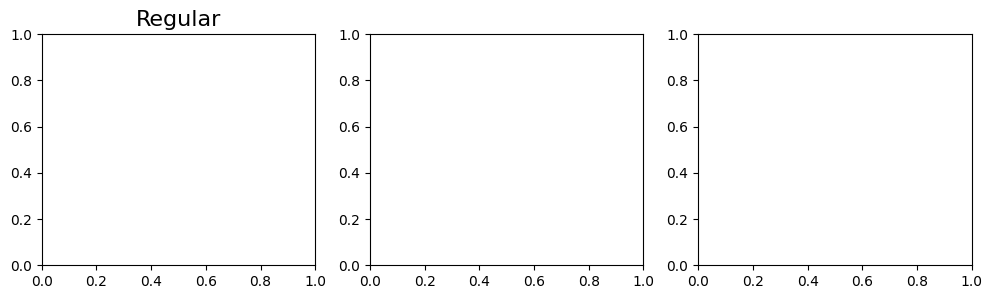

In [91]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
titles=['Regular', 'Poisson', 'Power-Law']
mean_sims1=[mean_reg_1,mean_poi_1,mean_pow_1]
mean_sims2=[mean_reg_2,mean_poi_2,mean_pow_2]
mean_fields_1 = [HOc_Reg_1,HOc_Poi_1,HOc_Pow_1]
mean_fields_2 = [HOc_Reg_2,HOc_Poi_2,HOc_Pow_2]
lambdas = np.linspace(0,2,len(mean_fields_1[i]))
N=1000
nth_sim=3
for i in range(0,3):
    ax[i].set_title(titles[i], fontsize=16)

    lambdas_sim=np.linspace(0,2,len(mean_sims1[i]))
    lambdas=np.linspace(0,2,len(mean_fields_1[i]))

    ax[i].scatter(lambdas_sim[::nth_sim],mean_sims2[i][::nth_sim]/N, marker='D',  s=100, facecolors='coral', alpha=0.5, edgecolors='darkred',  label=r'cedHO, $I_0=0.95$')
    ax[i].scatter(lambdas_sim[::nth_sim],mean_sims1[i][::nth_sim]/N, s=100, facecolors='skyblue', alpha=0.5, edgecolors='darkblue', label=r'cedHO, $I_0=0.05$')
    #ax[i].scatter(lambdas_sim[::nth_sim],mean_sims2[i][::nth_sim]/N, marker='D',  s=100, facecolors='coral', alpha=0.3, edgecolors='darkred',  label=r'cedHO, $I_0=0.95$')
    ax[i].plot(lambdas,mean_fields_1[i]/N,color='darkblue',lw=3, label=r'GA sim, $I_0=0.95$')
    ax[i].plot(lambdas,mean_fields_2[i]/N,color='darkred',lw=3, label=r'GA sim, $I_0=0.95$')
    ax[i].set_xlim((0,2))
    ax[i].set_xlabel(r'$\lambda_1$',fontsize=16)
    ax[0].set_ylabel(r'$\rho$',fontsize=16)
    ax[i].tick_params(axis='both', which='major', labelsize=14)
    if i==1:
        ax[i].legend()
plt.tight_layout()


#plt.savefig('fig1bottom.svg')

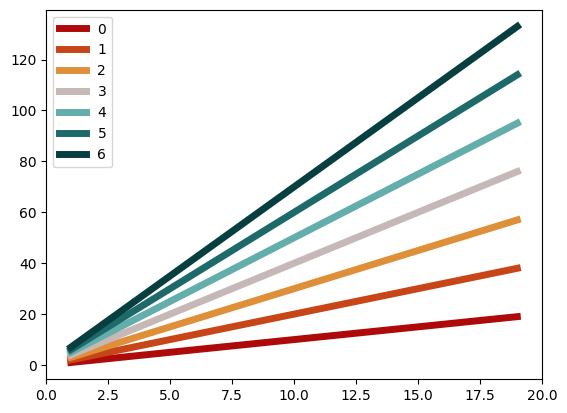

In [37]:
colors_1 = ['#ae0a0a', '#c74517', '#e08f39', '#c7b8b8', '#63adab', '#1e6a6a', '#073f40'] #['#580000', '#974013', '#dba164', '#d6d6d6', '#81bdbb', '#1e6b6a', '#003233']
colors_2 = ['#b35806','#f1a340','#fee0b6','#d8daeb','#998ec3','#542788']
colors_3 = ['#008c5c', '#33b983', '#002f64', '#0050ae', '#9b54f3', '#bf8cfc', '#680000', '#ac0000', '#c85b00', '#f98517']
x=range(1,20)
y=range(1,20)
i=1
for c in colors_1:
    plt.plot(x,np.array(y)*i,color=c, lw=5,label=i-1)
    i+=1

plt.xlim(0,20)
plt.legend()

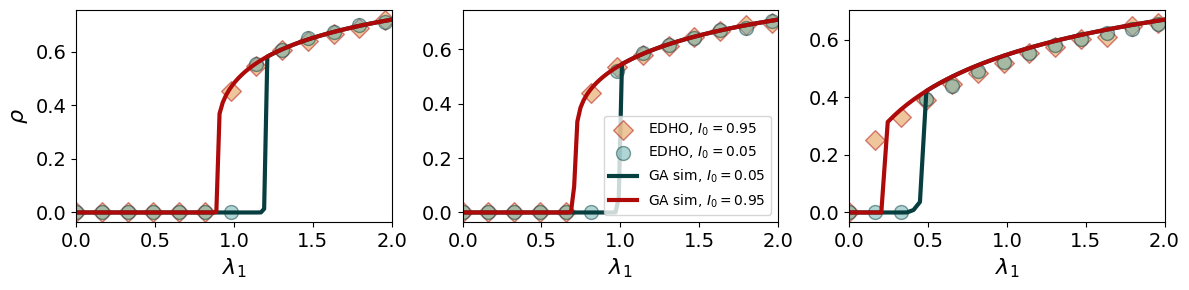

In [38]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
titles=['Regular', 'Poisson', 'Power-Law']
mean_sims1=[mean_reg_1,mean_poi_1,mean_pow_1]
mean_sims2=[mean_reg_2,mean_poi_2,mean_pow_2]
mean_fields_1 = [HOc_Reg_1,HOc_Poi_1,HOc_Pow_1]
mean_fields_2 = [HOc_Reg_2,HOc_Poi_2,HOc_Pow_2]
N=1000
nth_sim=4
for i in range(0,3):
    #ax[i].set_title(titles[i], fontsize=16)
    if i ==2:
        lambdas_sim=np.linspace(0,2,len(mean_sims1[i]))
        lambdas=np.linspace(0,2,len(mean_fields_1[i]))
    else:
        lambdas_sim=np.linspace(0,2,len(mean_sims1[i]))
        lambdas=np.linspace(0,2,len(mean_fields_1[i]))
    ax[i].scatter(lambdas_sim[::nth_sim],mean_sims2[i][::nth_sim]/N, marker='D',  s=100, facecolors=colors_1[2], alpha=0.5, edgecolors=colors_1[0],  label=r'EDHO, $I_0=0.95$')
    ax[i].scatter(lambdas_sim[::nth_sim],mean_sims1[i][::nth_sim]/N, s=100, facecolors=colors_1[4], alpha=0.5, edgecolors=colors_1[6], label=r'EDHO, $I_0=0.05$')
    #ax[i].scatter(lambdas_sim[::nth_sim],mean_sims2[i][::nth_sim]/N, marker='D',  s=100, facecolors='coral', alpha=0.3, edgecolors='darkred',  label=r'cedHO, $I_0=0.95$')
    ax[i].plot(lambdas,mean_fields_1[i]/N,color=colors_1[6],lw=3, label=r'GA sim, $I_0=0.05$')
    ax[i].plot(lambdas,mean_fields_2[i]/N,color=colors_1[0],lw=3, label=r'GA sim, $I_0=0.95$')
    ax[i].set_xlabel(r'$\lambda_1$',fontsize=16)
    ax[i].set_xlim((0,2))
    ax[0].set_ylabel(r'$\rho$',fontsize=16)
    ax[i].tick_params(axis='both', which='major', labelsize=14)
    if i==1:
        ax[i].legend()
plt.tight_layout()


plt.savefig('fig1bottom.svg')

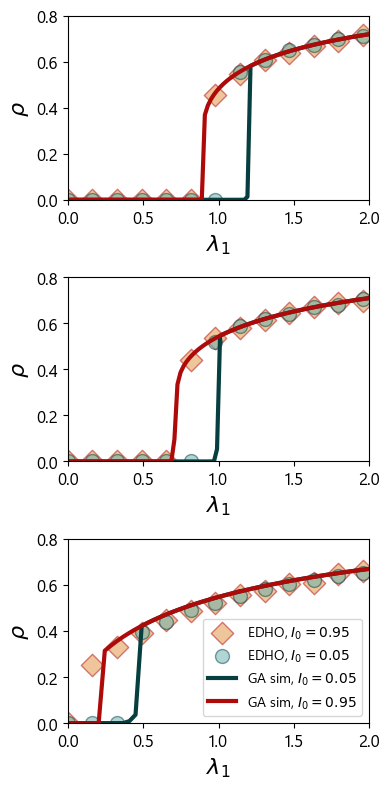

In [39]:
plt.rcParams['font.family'] = 'Segoe UI Variable' 
fig, ax = plt.subplots(3, 1, figsize=(4, 8))
titles=['Regular', 'Poisson', 'Power-Law']
mean_sims1=[mean_reg_1,mean_poi_1,mean_pow_1]
mean_sims2=[mean_reg_2,mean_poi_2,mean_pow_2]
mean_fields_1 = [HOc_Reg_1,HOc_Poi_1,HOc_Pow_1]
mean_fields_2 = [HOc_Reg_2,HOc_Poi_2,HOc_Pow_2]
N=1000
nth_sim=4
for i in range(0,3):
    #ax[i].set_title(titles[i], fontsize=16)
    if i ==2:
        lambdas_sim=np.linspace(0,2,len(mean_sims1[i]))
        lambdas=np.linspace(0,2,len(mean_fields_1[i]))
    else:
        lambdas_sim=np.linspace(0,2,len(mean_sims1[i]))
        lambdas=np.linspace(0,2,len(mean_fields_1[i]))
    ax[i].scatter(lambdas_sim[::nth_sim],mean_sims2[i][::nth_sim]/N, marker='D',  s=130, facecolors=colors_1[2], alpha=0.5, edgecolors=colors_1[0],  label=r'EDHO, $I_0=0.95$')
    ax[i].scatter(lambdas_sim[::nth_sim],mean_sims1[i][::nth_sim]/N, s=100, facecolors=colors_1[4], alpha=0.5, edgecolors=colors_1[6], label=r'EDHO, $I_0=0.05$')
    #ax[i].scatter(lambdas_sim[::nth_sim],mean_sims2[i][::nth_sim]/N, marker='D',  s=100, facecolors='coral', alpha=0.3, edgecolors='darkred',  label=r'cedHO, $I_0=0.95$')
    ax[i].plot(lambdas,mean_fields_1[i]/N,color=colors_1[6],lw=3, label=r'GA sim, $I_0=0.05$')
    ax[i].plot(lambdas,mean_fields_2[i]/N,color=colors_1[0],lw=3, label=r'GA sim, $I_0=0.95$')
    ax[i].set_xlim((0,2))
    ax[i].set_xlabel(r'$\lambda_1$',fontsize=16)
    ax[i].set_ylabel(r'$\rho$', fontsize=16)
    ax[i].set_xlim((0,2))
    ax[i].set_ylim((0,0.8))
    ax[i].tick_params(axis='both', which='major', labelsize=12)
                      
    if i==2:
        ax[i].legend()
plt.tight_layout()


#plt.savefig('fig1bottom_corr.svg')

In [ ]:
from scipy import stats

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


def plot_epidemic_scatter(beta_values, all_final_sizes, confidence=0.95,
                          ax=None, color=None, label=None, marker='o'):
    """
    Scatter plot of mean final epidemic size vs beta with 95% CI error bars.

    Parameters
    ----------
    beta_values : array-like
        List of beta (infectivity) values tested.
    all_final_sizes : list of list of float
        all_final_sizes[i] is a list of final epidemic sizes from multiple
        Gillespie runs at beta_values[i].
    confidence : float
        Confidence level for error bars.
    ax : matplotlib Axes, optional
    color : str, optional
    label : str, optional
    marker : str, optional

    Returns
    -------
    ax : matplotlib Axes
    """
    beta_values = np.asarray(beta_values)
    n_betas = len(beta_values)

    means = np.zeros(n_betas)
    err = np.zeros(n_betas)

    z = stats.norm.ppf(1 - (1 - confidence) / 2)

    for i, sizes in enumerate(all_final_sizes):
        sizes = np.asarray(sizes)
        means[i] = sizes.mean()
        se = sizes.std(ddof=1) / np.sqrt(len(sizes))
        err[i] = z * se

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    ax.errorbar(beta_values, means, yerr=err, fmt=marker, color=color or 'crimson',
                capsize=3, capthick=1.2, elinewidth=1.2, markersize=5,
                label=label or f'Mean ± {int(confidence*100)}% CI')

    ax.set_xlabel(r'Infectivity $\beta$')
    ax.set_ylabel('Final epidemic size')
    ax.legend()

    return ax

In [43]:
print(len(sim_poi_1[0]))

30
